# Modeling

## 1. Setup & load features

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score, average_precision_score
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

# Locate processed features robustly (notebook lives in regime_aware_churn_predictor/notebooks/)
def find_processed_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        for cand in (base / 'data' / 'processed', base / 'regime_aware_churn_predictor' / 'data' / 'processed'):
            if (cand / 'train_features.csv').exists():
                return cand
    raise FileNotFoundError('Could not locate data/processed/train_features.csv above ' + str(Path.cwd()))

PROC = find_processed_dir()
train = pd.read_csv(PROC / 'train_features.csv')
holdout = pd.read_csv(PROC / 'holdout_features.csv')
print('PROC =', PROC)
print('train  :', train.shape)
print('holdout:', holdout.shape)

PROC = F:\myWorks\python\regime-aware-churn-predictor\regime_aware_churn_predictor\data\processed
train  : (119, 72)
holdout: (108, 71)


## 1.2 Features / target split

In [2]:
y = train['churned'].astype(int)
X = train.drop(columns=['member_id', 'churned'])
X_hold = holdout.drop(columns=['member_id'])
hold_ids = holdout['member_id']

assert list(X.columns) == list(X_hold.columns), 'train/holdout feature columns differ!'
print('n features :', X.shape[1])
print('n train    :', len(y), '| churners:', int(y.sum()), f'({y.mean():.1%})')
print('n holdout  :', len(X_hold))

n features : 70
n train    : 119 | churners: 18 (15.1%)
n holdout  : 108


## 2. Cross-validated evaluation

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SEEDS = [0, 1, 7, 17, 42, 99, 123]   # multiple CV splits for robust precision@k (it's noisy with 18 positives)
K_FRAC = 0.06                        # campaign budget: target at most 6% of the base

def oof_proba(model, X, y, random_state=42):
    cv_s = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    return cross_val_predict(model, X, y, cv=cv_s, method='predict_proba')[:, 1]

def precision_at_k(y_true, proba, frac=K_FRAC):
    y_true = np.asarray(y_true)
    k = max(1, int(np.ceil(frac * len(y_true))))
    top = np.argsort(proba)[::-1][:k]            # the top-k members we'd target
    return y_true[top].mean()

def mean_precision_at_k(model, X, y, frac=K_FRAC, seeds=SEEDS):
    # average precision among the top-k targeted, across CV splits (the operating-point metric)
    return float(np.mean([precision_at_k(y, oof_proba(model, X, y, s), frac) for s in seeds]))

def score(y, proba):
    return {
        'brier': brier_score_loss(y, proba),
        'log_loss': log_loss(y, proba, labels=[0, 1]),
        'pr_auc': average_precision_score(y, proba),
        'roc_auc': roc_auc_score(y, proba),
    }

BASE_BRIER = brier_score_loss(y, np.full(len(y), y.mean()))
print(f'Baseline Brier (flat {y.mean():.3f}) = {BASE_BRIER:.4f}  | random precision@6% = base rate {y.mean():.3f}')

Baseline Brier (flat 0.151) = 0.1284  | random precision@6% = base rate 0.151


## 2.2 Regularization sweep (choose `C`)

In [4]:
C_GRID = [0.01, 0.03, 0.05, 0.1, 0.3, 1.0]

def make_logreg(penalty, C):
    solver = 'liblinear' if penalty == 'l1' else 'lbfgs'
    return Pipeline([('scaler', StandardScaler()),
                     ('clf', LogisticRegression(penalty=penalty, C=C, solver=solver, max_iter=5000))])

sweep_rows = []
for penalty in ['l2', 'l1']:
    for C in C_GRID:
        model = make_logreg(penalty, C)
        proba = oof_proba(model, X, y)                       # single-split, for calibration/ranking display
        sweep_rows.append({'penalty': penalty, 'C': C, **score(y, proba),
                           'prec@6%': mean_precision_at_k(model, X, y),   # selection metric (multi-split)
                           'beats_baseline': brier_score_loss(y, proba) < BASE_BRIER})
sweep = pd.DataFrame(sweep_rows)
sweep.round(4)

,penalty,C,brier,log_loss,pr_auc,roc_auc,prec@6%,beats_baseline
0,l2,0.01,0.1224,0.4106,0.2554,0.5990,0.2679,True
1,l2,0.03,0.1236,0.4174,0.2612,0.6001,0.2679,True
2,l2,0.05,0.1259,0.4289,0.2669,0.6034,0.3036,True
3,l2,0.10,0.1322,0.4583,0.2676,0.5990,0.3036,False
4,l2,0.30,0.1562,0.5718,0.2680,0.5985,0.3214,False
5,l2,1.00,0.1820,1.0313,0.2664,0.6029,0.2857,False
6,l1,0.01,0.2500,0.6931,0.1513,0.5000,0.3750,False
7,l1,0.03,0.2493,0.6917,0.1434,0.4637,0.1964,False
8,l1,0.05,0.1727,0.5349,0.1430,0.4629,0.1607,False
9,l1,0.10,0.1397,0.4581,0.1407,0.4733,0.1607,False


In [5]:
best_rows = []
for pen, df in sweep.groupby('penalty'):
    ok = df[df['brier'] < BASE_BRIER]
    if len(ok):
        pick = ok.sort_values(['prec@6%', 'brier'], ascending=[False, True]).iloc[0]
    else:
        pick = df.sort_values('brier').iloc[0]   # fallback: most-calibrated config (penalty kept for comparison)
    best_rows.append(pick)
best = pd.DataFrame(best_rows)
best_C = {r['penalty']: float(r['C']) for _, r in best.iterrows()}
print('Selected C (beats-baseline Brier, then max precision@6%):', best_C)
best.set_index('penalty')[['C', 'prec@6%', 'brier', 'pr_auc', 'roc_auc']].round(4)

Selected C (beats-baseline Brier, then max precision@6%): {'l1': 0.3, 'l2': 0.05}


,C,prec@6%,brier,pr_auc,roc_auc
penalty,,,,,
l1,0.30,0.2857,0.1317,0.2896,0.5792
l2,0.05,0.3036,0.1259,0.2669,0.6034


## 2.3 Final Tier-1 candidates & results

In [6]:
models = {
    'baseline_prior': DummyClassifier(strategy='prior'),
    'logreg_l2': make_logreg('l2', best_C['l2']),
    'logreg_l1': make_logreg('l1', best_C['l1']),
}

oof = {}
rows = []
for name, model in models.items():
    proba = oof_proba(model, X, y)
    oof[name] = proba
    rows.append({'model': name, **score(y, proba), 'prec@6%': mean_precision_at_k(model, X, y)})
results = pd.DataFrame(rows).set_index('model').sort_values('brier').round(4)
print(f'Baseline Brier reference = {BASE_BRIER:.4f}  (any model must beat this)')
results

Baseline Brier reference = 0.1284  (any model must beat this)


,brier,log_loss,pr_auc,roc_auc,prec@6%
model,,,,,
logreg_l2,0.1259,0.4289,0.2669,0.6034,0.3036
baseline_prior,0.1286,0.4257,0.1430,0.4629,0.1607
logreg_l1,0.1317,0.4398,0.2896,0.5792,0.2857


## 2.4 ROC curve — best model

Best model: logreg_l2 -> refit on all 119 training rows


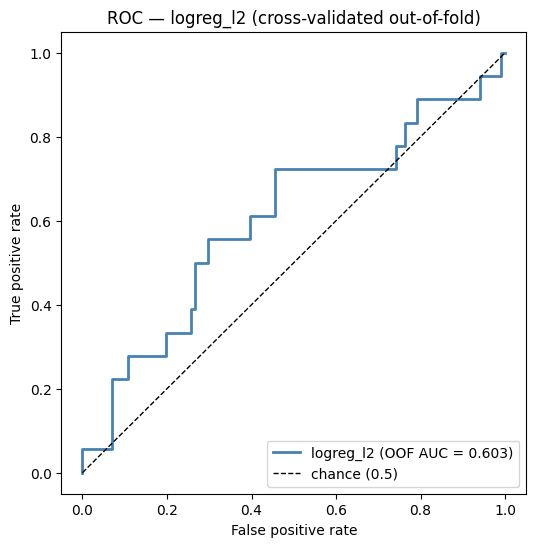

In [7]:
from sklearn.metrics import roc_curve

# Select best model: among candidates that beat the baseline Brier (calibration guard), highest precision@6%.
cand = results.drop(index='baseline_prior')
ok = cand[cand['brier'] < BASE_BRIER]
pool = ok if len(ok) else cand
best_name = pool.sort_values('prec@6%', ascending=False).index[0]
best_model = models[best_name].fit(X, y)   # refit on the FULL training set (deployment model)
print('Best model:', best_name, '-> refit on all', len(y), 'training rows')

# ROC from cross-validated out-of-fold predictions (honest, not in-sample)
fpr, tpr, _ = roc_curve(y, oof[best_name])
auc_oof = roc_auc_score(y, oof[best_name])
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'{best_name} (OOF AUC = {auc_oof:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='chance (0.5)')
plt.xlabel('False positive rate'); plt.ylabel('True positive rate')
plt.title(f'ROC — {best_name} (cross-validated out-of-fold)')
plt.legend(loc='lower right'); plt.show()

## 2.5 Most important features — best model

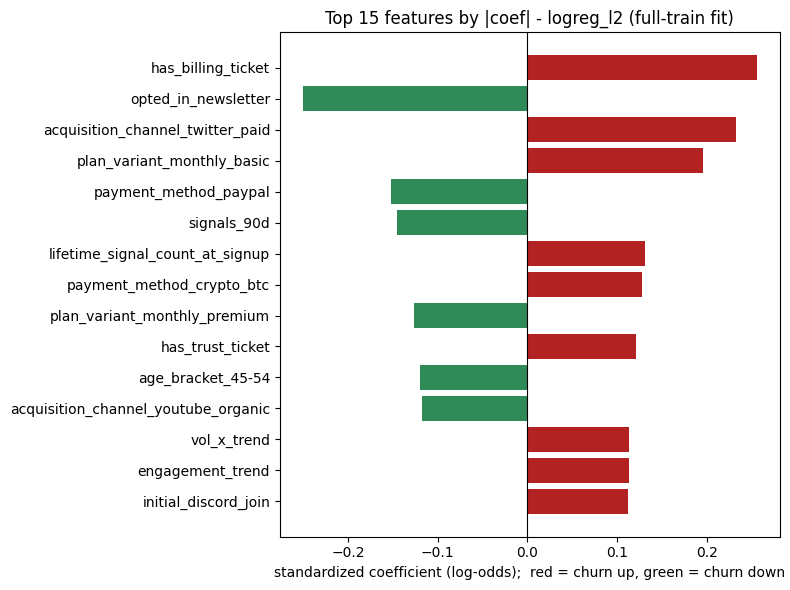

has_billing_ticket                     0.256
opted_in_newsletter                   -0.251
acquisition_channel_twitter_paid       0.233
plan_variant_monthly_basic             0.196
payment_method_paypal                 -0.152
signals_90d                           -0.146
lifetime_signal_count_at_signup        0.132
payment_method_crypto_btc              0.128
plan_variant_monthly_premium          -0.126
has_trust_ticket                       0.121
age_bracket_45-54                     -0.120
acquisition_channel_youtube_organic   -0.117
vol_x_trend                            0.113
engagement_trend                       0.113
initial_discord_join                   0.112
dtype: float64

In [8]:
clf = best_model.named_steps['clf']
coef = pd.Series(clf.coef_[0], index=X.columns)
top = coef.reindex(coef.abs().sort_values(ascending=False).index).head(15)[::-1]
colors = ['firebrick' if v > 0 else 'seagreen' for v in top.values]

plt.figure(figsize=(8, 6))
plt.barh(top.index, top.values, color=colors)
plt.axvline(0, color='k', lw=0.8)
plt.title(f'Top 15 features by |coef| - {best_name} (full-train fit)')
plt.xlabel('standardized coefficient (log-odds);  red = churn up, green = churn down')
plt.tight_layout(); plt.show()

top[::-1].round(3)

## 2.6 Precision & recall vs threshold

Best model: logreg_l2 | OOF probabilities | n=119, churners=18 (15.1%)


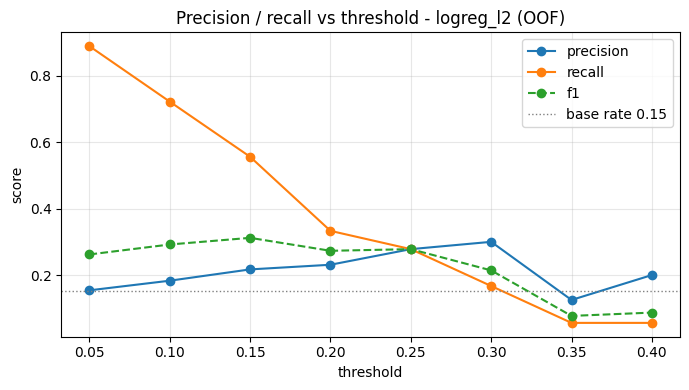

,threshold,n_flagged,pct_flagged,precision,recall,f1
0,0.05,104,87.4,0.154,0.889,0.262
1,0.10,71,59.7,0.183,0.722,0.292
2,0.15,46,38.7,0.217,0.556,0.312
3,0.20,26,21.8,0.231,0.333,0.273
4,0.25,18,15.1,0.278,0.278,0.278
5,0.30,10,8.4,0.300,0.167,0.214
6,0.35,8,6.7,0.125,0.056,0.077
7,0.40,5,4.2,0.200,0.056,0.087


In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Use the best model's cross-validated OOF probabilities
proba = oof[best_name]
thresholds = np.round(np.arange(0.05, 0.41, 0.05), 2)

rows = []
for t in thresholds:
    pred = (proba >= t).astype(int)
    n = int(pred.sum())
    rows.append({
        'threshold': t,
        'n_flagged': n,
        'pct_flagged': round(100 * n / len(y), 1),
        'precision': round(precision_score(y, pred, zero_division=0), 3),
        'recall': round(recall_score(y, pred, zero_division=0), 3),
        'f1': round(f1_score(y, pred, zero_division=0), 3),
    })
thr = pd.DataFrame(rows)
print(f'Best model: {best_name} | OOF probabilities | n={len(y)}, churners={int(y.sum())} ({y.mean():.1%})')

plt.figure(figsize=(7, 4))
plt.plot(thr['threshold'], thr['precision'], marker='o', label='precision')
plt.plot(thr['threshold'], thr['recall'], marker='o', label='recall')
plt.plot(thr['threshold'], thr['f1'], marker='o', ls='--', label='f1')
plt.axhline(y.mean(), color='grey', ls=':', lw=1, label=f'base rate {y.mean():.2f}')
plt.xlabel('threshold'); plt.ylabel('score')
plt.title(f'Precision / recall vs threshold - {best_name} (OOF)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

thr

## 2.7 Calibration check (reliability curve)

Confirm the best model's probabilities are calibrated

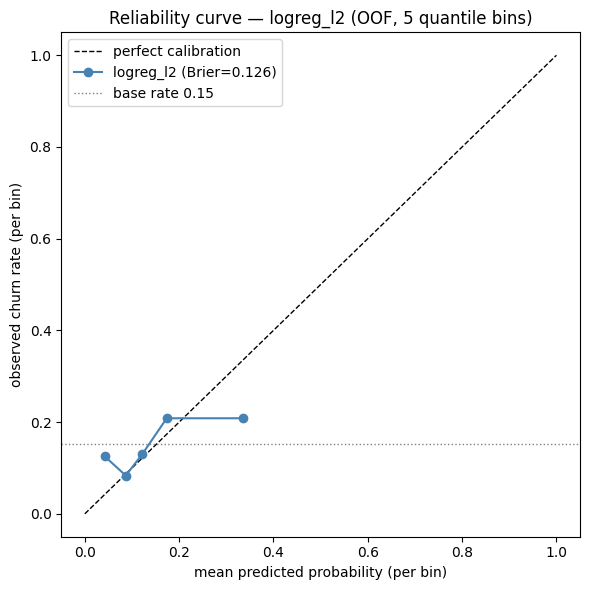

Brier = 0.1259  vs baseline 0.1284  ->  calibrated (beats baseline)
bin mean predicted: [0.042 0.087 0.122 0.174 0.335]
bin observed rate : [0.125 0.083 0.13  0.208 0.208]


In [10]:
# Reliability curve: bin OOF predictions and compare mean predicted prob vs observed churn rate.
proba_oof = oof[best_name]
frac_pos, mean_pred = calibration_curve(y, proba_oof, n_bins=5, strategy='quantile')
brier = brier_score_loss(y, proba_oof)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='perfect calibration')
plt.plot(mean_pred, frac_pos, marker='o', color='steelblue',
         label=f'{best_name} (Brier={brier:.3f})')
plt.axhline(y.mean(), color='grey', ls=':', lw=1, label=f'base rate {y.mean():.2f}')
plt.xlabel('mean predicted probability (per bin)')
plt.ylabel('observed churn rate (per bin)')
plt.title(f'Reliability curve — {best_name} (OOF, 5 quantile bins)')
plt.legend(loc='upper left'); plt.tight_layout(); plt.show()

print(f'Brier = {brier:.4f}  vs baseline {BASE_BRIER:.4f}  ->  {"calibrated (beats baseline)" if brier < BASE_BRIER else "worse than baseline"}')
print('bin mean predicted:', np.round(mean_pred, 3))
print('bin observed rate :', np.round(frac_pos, 3))

## 3. Holdout predictions with per-member explanations

In [11]:
# Score ALL holdout members with the deployment model, and explain each prediction.
# For logistic regression the per-feature contribution to the log-odds is coef * standardized_value,
# so the largest-magnitude contributions are literally the reasons for that member's score.
scaler = best_model.named_steps['scaler']
clf = best_model.named_steps['clf']
coef = clf.coef_[0]
feat_names = X_hold.columns.to_numpy()

Xh_scaled = scaler.transform(X_hold)
contrib = Xh_scaled * coef                      # (n_holdout, n_features) contributions to log-odds

def top_drivers(i, k=3):
    c = contrib[i]
    idx = np.argsort(np.abs(c))[::-1][:k]        # top features by |contribution| for this member
    return ', '.join(f"{feat_names[j]} ({'+' if c[j] >= 0 else '-'}{abs(c[j]):.2f})" for j in idx)

pred = pd.DataFrame({
    'member_id': hold_ids.values,
    'churn_probability': best_model.predict_proba(X_hold)[:, 1],
})
pred['top_drivers (+ pushes churn up, - down)'] = [top_drivers(i) for i in range(len(pred))]
pred = pred.sort_values('churn_probability', ascending=False).reset_index(drop=True)
pred['churn_probability'] = pred['churn_probability'].round(4)

out = PROC / 'holdout_predictions_explained.csv'
pred.to_csv(out, index=False)
print(f'Scored all {len(pred)} holdout members with {best_name}; saved -> {out}')

pd.set_option('display.max_rows', 200)
pred

Scored all 108 holdout members with logreg_l2; saved -> F:\myWorks\python\regime-aware-churn-predictor\regime_aware_churn_predictor\data\processed\holdout_predictions_explained.csv


,member_id,churn_probability,"top_drivers (+ pushes churn up, - down)"
0,M10217,0.5157,"tickets_90d (+0.63), acquisition_channel_twitt..."
1,M10159,0.4414,"acquisition_channel_twitter_paid (+0.53), tick..."
2,M10271,0.4309,"acquisition_channel_twitter_paid (+0.53), paym..."
3,M10286,0.3940,"acquisition_channel_twitter_paid (+0.53), plan..."
4,M10281,0.3531,"lifetime_signal_count_at_signup (+0.28), plan_..."
5,M10158,0.3199,"has_billing_ticket (+0.36), opted_in_newslette..."
6,M10113,0.3189,"tickets_90d (+0.46), has_billing_ticket (+0.36..."
7,M10212,0.3050,"tickets_90d (+0.46), has_billing_ticket (+0.36..."
8,M10029,0.3029,"tickets_90d (+0.98), signals_total (-0.39), ha..."
9,M10279,0.2997,"acquisition_channel_twitter_paid (+0.53), paym..."


## 4. Prior-shift for the holdout regime

The model is trained on a **bear** regime the holdout is a **recovery** regime where churn is likely lower, so the raw probabilities may run high. A **prior-shift** rescales them to an assumed base rate by shifting the log-odds — `logit(π_target) − logit(π_train)`.

In [12]:
def prior_shift(p, pi_target, pi_train):
    """Label-shift correction: rescale probabilities to a new base rate by shifting the log-odds
    by logit(pi_target) - logit(pi_train). Monotonic -> ranking and top-k targeting are UNCHANGED."""
    p = np.clip(np.asarray(p, dtype=float), 1e-12, 1 - 1e-12)
    delta = np.log(pi_target / (1 - pi_target)) - np.log(pi_train / (1 - pi_train))
    return 1.0 / (1.0 + np.exp(-(np.log(p / (1 - p)) + delta)))

PI_TRAIN = float(y.mean())      # 0.151 = bear-regime training base rate
PI_TARGET = 0.10                # ASSUMED recovery base rate (judgment call -- holdout has no labels). Tune/recalibrate.

p_raw = pred['churn_probability'].values
p_shift = prior_shift(p_raw, PI_TARGET, PI_TRAIN)

print(f'pi_train = {PI_TRAIN:.3f}  ->  pi_target (assumed recovery) = {PI_TARGET:.3f}')
print(f'mean predicted churn: raw = {p_raw.mean():.3f}  ->  shifted = {p_shift.mean():.3f}')
print('ranking unchanged (top-6% targeting identical):',
      np.array_equal(np.argsort(-p_raw), np.argsort(-p_shift)))

pred_shifted = pred.copy()
pred_shifted['churn_probability_shifted'] = np.round(p_shift, 4)
pred_shifted[['member_id', 'churn_probability', 'churn_probability_shifted']].head(8)

pi_train = 0.151  ->  pi_target (assumed recovery) = 0.100
mean predicted churn: raw = 0.144  ->  shifted = 0.098
ranking unchanged (top-6% targeting identical): True


,member_id,churn_probability,churn_probability_shifted
0,M10217,0.5157,0.3990
1,M10159,0.4414,0.3301
2,M10271,0.4309,0.3207
3,M10286,0.3940,0.2884
4,M10281,0.3531,0.2539
5,M10158,0.3199,0.2268
6,M10113,0.3189,0.2260
7,M10212,0.3050,0.2148


## 5. `predictions.csv`

In [13]:
PRED_PATH = PROC.parent.parent / 'predictions.csv'   # regime_aware_churn_predictor/predictions.csv

USE_PRIOR_SHIFT = True
prob_col = 'churn_probability_shifted' if USE_PRIOR_SHIFT else 'churn_probability'
src = pred_shifted if USE_PRIOR_SHIFT else pred

submission = src[['member_id', prob_col]].rename(columns={prob_col: 'churn_probability'}).copy()
submission['churn_probability'] = submission['churn_probability'].clip(0, 1).round(6)

submission.to_csv(PRED_PATH, index=False)
print(f'Wrote {len(submission)} rows -> {PRED_PATH}')
print(f'columns = {list(submission.columns)} | prior_shift = {USE_PRIOR_SHIFT} | mean prob = {submission["churn_probability"].mean():.3f}')
submission.head()

Wrote 108 rows -> F:\myWorks\python\regime-aware-churn-predictor\regime_aware_churn_predictor\predictions.csv
columns = ['member_id', 'churn_probability'] | prior_shift = True | mean prob = 0.098


,member_id,churn_probability
0,M10217,0.3990
1,M10159,0.3301
2,M10271,0.3207
3,M10286,0.2884
4,M10281,0.2539


## 6. Operating point & net-margin analysis

Translate scores into the business decision. For a set of targeted members:

`net margin = (churners caught × 22% save × $190 LTV) − (members targeted × $28 cost)`

which means each targeted member only pays off if precision clears **break-even = 28 / (0.22 × 190) ≈ 0.67**.

We sweep the operating point (target the top-K by score), estimate net margin on the **training OOF** (only labeled data), and pick the best point **within the 6% budget cap**. The holdout is unlabeled, so this is the best available estimate — and since the holdout is a *recovery* regime (lower churn → lower precision), realized net margin there is likely **worse**, not better.

Economics: $28/target, save 22%, LTV $190  ->  break-even precision = 0.670


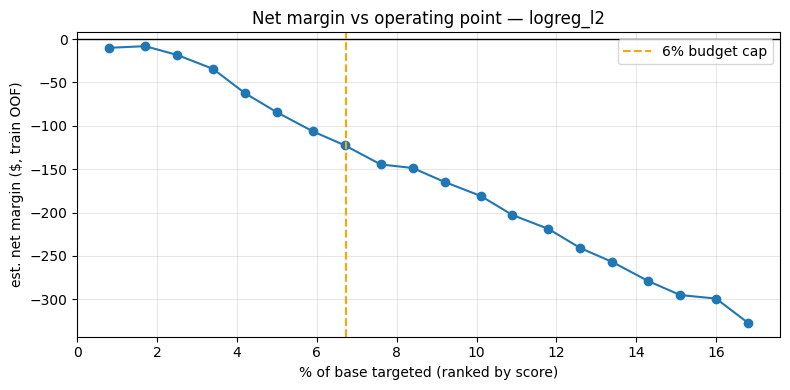


6% budget = top 8 of 119 | precision@6% = 0.304 vs break-even 0.67
Best operating point within budget: top 2 (1.7% of base) -> est. net margin $-8.2 (precision 0.571)
CONCLUSION: net margin <= 0 at every operating point -> NOT profitable as priced.
Recommend: target only the very top (~2% highest-confidence, near break-even),
           or hold the campaign until uplift is modeled / offer economics improve.


,top_K,pct_base,precision,churners_caught,net_margin_usd
0,1,0.8,0.429,0.4,-10.1
1,2,1.7,0.571,1.1,-8.2
2,3,2.5,0.524,1.6,-18.3
3,4,3.4,0.464,1.9,-34.4
4,5,4.2,0.371,1.9,-62.4
5,6,5.0,0.333,2.0,-84.4
6,7,5.9,0.306,2.1,-106.4
7,8,6.7,0.304,2.4,-122.5
8,9,7.6,0.286,2.6,-144.5
9,10,8.4,0.314,3.1,-148.6


In [14]:
COST, SAVE, LTV = 28, 0.22, 190
BREAKEVEN = COST / (SAVE * LTV)
print(f'Economics: ${COST}/target, save {SAVE:.0%}, LTV ${LTV}  ->  break-even precision = {BREAKEVEN:.3f}')

# Net margin per operating point, estimated on TRAIN via multi-seed OOF (the only labeled data we have).
#   net = (churners caught x save rate x LTV)  -  (members targeted x cost)
yv = np.asarray(y)
def net_margin_curve(model, Ks, seeds=SEEDS):
    rows = []
    for K in Ks:
        nets, precs, tps = [], [], []
        for s in seeds:
            p = oof_proba(model, X, y, s)
            top = np.argsort(p)[::-1][:K]
            tp = yv[top].sum()
            nets.append(tp * SAVE * LTV - K * COST); precs.append(tp / K); tps.append(tp)
        rows.append({'top_K': K, 'pct_base': round(100 * K / len(yv), 1),
                     'precision': round(np.mean(precs), 3),
                     'churners_caught': round(np.mean(tps), 1),
                     'net_margin_usd': round(np.mean(nets), 1)})
    return pd.DataFrame(rows)

opc = net_margin_curve(models[best_name], list(range(1, 21)))
budget_k = int(np.ceil(K_FRAC * len(yv)))    # 6% of base

plt.figure(figsize=(8, 4))
plt.plot(opc['pct_base'], opc['net_margin_usd'], marker='o')
plt.axhline(0, color='k', lw=1)
plt.axvline(100 * budget_k / len(yv), color='orange', ls='--', label='6% budget cap')
plt.xlabel('% of base targeted (ranked by score)'); plt.ylabel('est. net margin ($, train OOF)')
plt.title(f'Net margin vs operating point — {best_name}'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

within = opc[opc['top_K'] <= budget_k]
best_op = within.loc[within['net_margin_usd'].idxmax()]
print(f"\n6% budget = top {budget_k} of {len(yv)} | precision@6% = {within.iloc[-1]['precision']} vs break-even {BREAKEVEN:.2f}")
print(f"Best operating point within budget: top {int(best_op['top_K'])} ({best_op['pct_base']}% of base) "
      f"-> est. net margin ${best_op['net_margin_usd']} (precision {best_op['precision']})")
if best_op['net_margin_usd'] <= 0:
    print('CONCLUSION: net margin <= 0 at every operating point -> NOT profitable as priced.')
    print('Recommend: target only the very top (~2% highest-confidence, near break-even),')
    print('           or hold the campaign until uplift is modeled / offer economics improve.')
opc